📊 BUILDING WALMART SALES DASHBOARD - CLEAN VERSION

📊 Dataset: 10,000 rows, 20 columns
💰 Total Revenue: $1,155,753.96
📈 Time Period: 2019-01-01 00:00:00 to 2023-12-31 00:00:00

🤖 Training ML Models for Dashboard...
✅ ML Models trained successfully!


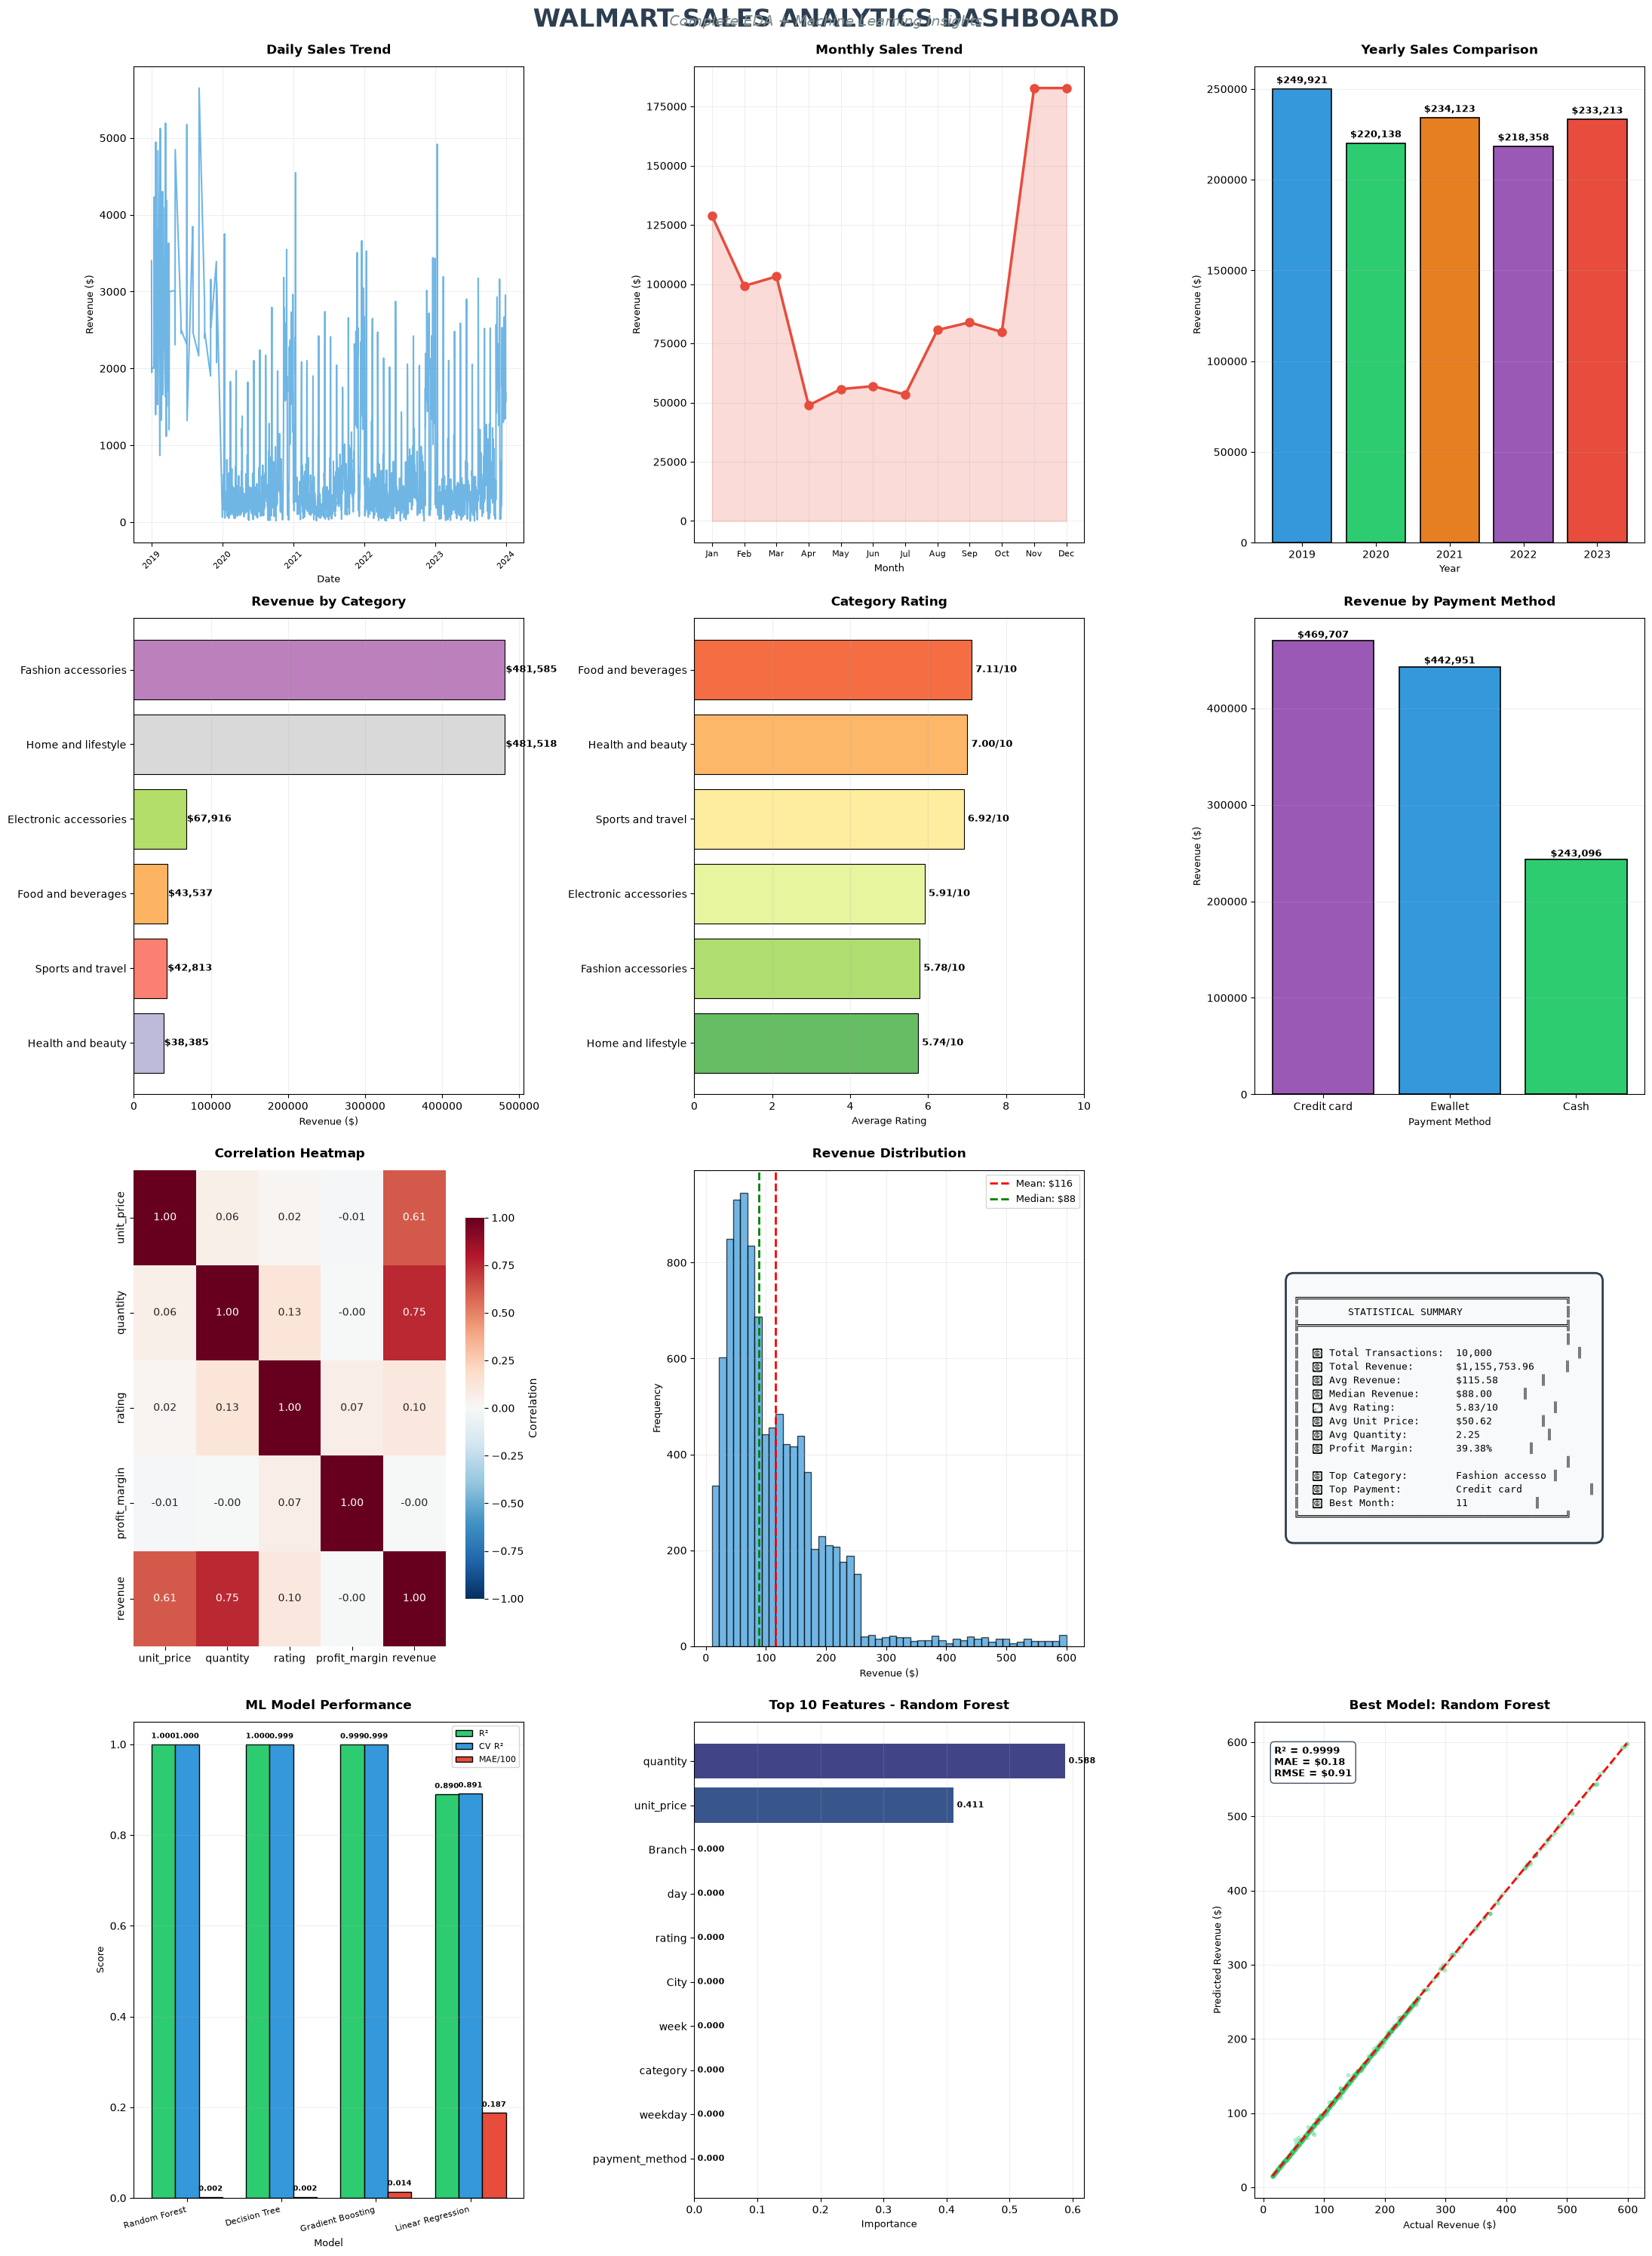


📊 DASHBOARD COMPLETE!

📈 DASHBOARD COMPONENTS INCLUDED:

1️⃣ SALES OVER TIME:
   ✅ Daily Sales Trend
   ✅ Monthly Sales Trend (Seasonality)
   ✅ Yearly Sales Comparison

2️⃣ CATEGORY & PAYMENT ANALYSIS:
   ✅ Revenue by Category
   ✅ Category Ratings
   ✅ Revenue by Payment Method

3️⃣ CORRELATION & DISTRIBUTION:
   ✅ Correlation Heatmap
   ✅ Revenue Distribution
   ✅ Statistical Summary

4️⃣ MACHINE LEARNING INSIGHTS:
   ✅ Model Performance (R², MAE, CV)
   ✅ Top 10 Feature Importance
   ✅ Best Model Summary + Actual vs Predicted

✅ Clean dashboard with all analytics! No overlapping charts.


In [3]:
# ============================================================================
# COMPLETE WALMART SALES DASHBOARD - CLEAN VERSION (NO OVERLAPPING)
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
import warnings
warnings.filterwarnings('ignore')

print("=" * 100)
print("📊 BUILDING WALMART SALES DASHBOARD - CLEAN VERSION")
print("=" * 100)

# ============================================================================
# DATA PREPARATION
# ============================================================================

df = pd.read_csv(r'C:\Users\Usman Ahmad\Desktop\vs code\Datascience- project\Walmart_Cleaned.csv', parse_dates=['date'])
df['revenue'] = df['unit_price'] * df['quantity']
df['is_weekend'] = df['weekday'].isin([6, 7]).astype(int)

# Create holiday indicator
if 'is_holiday' not in df.columns:
    holidays = ['01-01', '05-25', '07-04', '09-07', '11-26', '12-25']
    df['is_holiday'] = df['date'].dt.strftime('%m-%d').isin(holidays).astype(int)

print(f"\n📊 Dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"💰 Total Revenue: ${df['revenue'].sum():,.2f}")
print(f"📈 Time Period: {df['date'].min()} to {df['date'].max()}")

# ============================================================================
# RUN ML MODELS FOR DASHBOARD
# ============================================================================

print("\n🤖 Training ML Models for Dashboard...")

# Prepare features
features = ['unit_price', 'quantity', 'rating', 'profit_margin', 
            'year', 'month', 'week', 'day', 'quarter', 'weekday', 'is_weekend', 'is_holiday',
            'Branch', 'City', 'category', 'payment_method']

X = df[features].copy()
y = df['revenue']

# Encode categorical
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

# Scale features
scaler = StandardScaler()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
X_scaled = X.copy()
X_scaled[numerical_cols] = scaler.fit_transform(X[numerical_cols])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train models
models = {
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42, n_estimators=100),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=10),
    'Linear Regression': LinearRegression()
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2': r2_score(y_test, y_pred),
        'CV': cross_val_score(model, X_train, y_train, cv=5, scoring='r2').mean(),
        'Predictions': y_pred
    }

print("✅ ML Models trained successfully!")

# ============================================================================
# CREATE DASHBOARD - 4 ROWS x 3 COLUMNS (CLEAN)
# ============================================================================

fig = plt.figure(figsize=(22, 30))
fig.patch.set_facecolor('white')

# Main Title
fig.suptitle('WALMART SALES ANALYTICS DASHBOARD', 
             fontsize=24, fontweight='bold', color='#2c3e50', y=0.995)

# Subtitle
plt.figtext(0.5, 0.987, 'Complete EDA + Machine Learning Insights', 
            ha='center', fontsize=14, color='#7f8c8d', style='italic')

# Adjust spacing with more space between rows
plt.subplots_adjust(left=0.07, right=0.93, bottom=0.03, top=0.96, 
                    wspace=0.30, hspace=0.50)

# ============================================================================
# ROW 1: SALES OVER TIME (3 Charts)
# ============================================================================

# 1.1 Daily Sales Trend
ax1 = plt.subplot(4, 3, 1)
daily_sales = df.groupby('date')['revenue'].sum().reset_index()
ax1.plot(daily_sales['date'], daily_sales['revenue'], color='#3498db', linewidth=1.5, alpha=0.7)
ax1.set_title('Daily Sales Trend', fontsize=12, fontweight='bold', pad=12)
ax1.set_xlabel('Date', fontsize=9)
ax1.set_ylabel('Revenue ($)', fontsize=9)
ax1.tick_params(axis='x', rotation=45, labelsize=8)
ax1.grid(True, alpha=0.2)

# 1.2 Monthly Sales Trend
ax2 = plt.subplot(4, 3, 2)
monthly_sales = df.groupby('month')['revenue'].sum().reset_index()
ax2.plot(monthly_sales['month'], monthly_sales['revenue'], 
         marker='o', linewidth=2.5, color='#e74c3c', markersize=8)
ax2.fill_between(monthly_sales['month'], 0, monthly_sales['revenue'], alpha=0.2, color='#e74c3c')
ax2.set_title('Monthly Sales Trend', fontsize=12, fontweight='bold', pad=12)
ax2.set_xlabel('Month', fontsize=9)
ax2.set_ylabel('Revenue ($)', fontsize=9)
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], fontsize=8)
ax2.grid(True, alpha=0.2)

# 1.3 Yearly Sales Comparison
ax3 = plt.subplot(4, 3, 3)
yearly_sales = df.groupby('year')['revenue'].sum().reset_index()
colors = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6', '#e74c3c']
bars = ax3.bar(yearly_sales['year'], yearly_sales['revenue'], 
               color=colors[:len(yearly_sales)], edgecolor='black', linewidth=1.2)
ax3.set_title('Yearly Sales Comparison', fontsize=12, fontweight='bold', pad=12)
ax3.set_xlabel('Year', fontsize=9)
ax3.set_ylabel('Revenue ($)', fontsize=9)
ax3.grid(True, alpha=0.2, axis='y')

for bar, val in zip(bars, yearly_sales['revenue']):
    ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2000,
            f'${val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# ============================================================================
# ROW 2: CATEGORY ANALYSIS + PAYMENT METHOD
# ============================================================================

# 2.1 Category Revenue
ax4 = plt.subplot(4, 3, 4)
category_revenue = df.groupby('category')['revenue'].sum().sort_values(ascending=True)
colors = plt.cm.Set3(np.linspace(0.2, 0.8, len(category_revenue)))
bars = ax4.barh(category_revenue.index, category_revenue.values, color=colors, edgecolor='black', linewidth=0.8)
ax4.set_title('Revenue by Category', fontsize=12, fontweight='bold', pad=12)
ax4.set_xlabel('Revenue ($)', fontsize=9)
ax4.grid(True, alpha=0.2, axis='x')

for bar, val in zip(bars, category_revenue.values):
    ax4.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=9, fontweight='bold')

# 2.2 Category Rating
ax5 = plt.subplot(4, 3, 5)
category_rating = df.groupby('category')['rating'].mean().sort_values(ascending=True)
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(category_rating)))[::-1]
bars = ax5.barh(category_rating.index, category_rating.values, color=colors, edgecolor='black', linewidth=0.8)
ax5.set_title('Category Rating', fontsize=12, fontweight='bold', pad=12)
ax5.set_xlabel('Average Rating', fontsize=9)
ax5.set_xlim(0, 10)
ax5.grid(True, alpha=0.2, axis='x')

for bar, val in zip(bars, category_rating.values):
    ax5.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}/10', va='center', fontsize=9, fontweight='bold')

# 2.3 Payment Method Analysis
ax6 = plt.subplot(4, 3, 6)
payment_revenue = df.groupby('payment_method')['revenue'].sum().sort_values(ascending=False)
colors = ['#9b59b6', '#3498db', '#2ecc71']
bars = ax6.bar(payment_revenue.index, payment_revenue.values, 
               color=colors, edgecolor='black', linewidth=1.2)
ax6.set_title('Revenue by Payment Method', fontsize=12, fontweight='bold', pad=12)
ax6.set_xlabel('Payment Method', fontsize=9)
ax6.set_ylabel('Revenue ($)', fontsize=9)
ax6.grid(True, alpha=0.2, axis='y')

for bar, val in zip(bars, payment_revenue.values):
    ax6.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1000,
            f'${val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# ============================================================================
# ROW 3: CORRELATION + DISTRIBUTION
# ============================================================================

# 3.1 Correlation Heatmap
ax7 = plt.subplot(4, 3, 7)
corr_cols = ['unit_price', 'quantity', 'rating', 'profit_margin', 'revenue']
corr_matrix = df[corr_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, vmin=-1, vmax=1, ax=ax7, 
            cbar_kws={'label': 'Correlation', 'shrink': 0.8},
            annot_kws={'size': 10})
ax7.set_title('Correlation Heatmap', fontsize=12, fontweight='bold', pad=12)

# 3.2 Revenue Distribution
ax8 = plt.subplot(4, 3, 8)
ax8.hist(df['revenue'], bins=50, color='#3498db', edgecolor='black', alpha=0.7)
ax8.axvline(df['revenue'].mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Mean: ${df["revenue"].mean():.0f}')
ax8.axvline(df['revenue'].median(), color='green', linestyle='--', linewidth=2,
            label=f'Median: ${df["revenue"].median():.0f}')
ax8.set_title('Revenue Distribution', fontsize=12, fontweight='bold', pad=12)
ax8.set_xlabel('Revenue ($)', fontsize=9)
ax8.set_ylabel('Frequency', fontsize=9)
ax8.legend(fontsize=9)
ax8.grid(True, alpha=0.2)

# 3.3 Statistical Summary
ax9 = plt.subplot(4, 3, 9)
ax9.axis('off')

stats_text = f"""
╔════════════════════════════════════════════╗
║        STATISTICAL SUMMARY                 ║
╠════════════════════════════════════════════╣
║                                            ║
║  📊 Total Transactions:  {len(df):,}              ║
║  💰 Total Revenue:       ${df['revenue'].sum():,.2f}     ║
║  📈 Avg Revenue:         ${df['revenue'].mean():,.2f}       ║
║  📉 Median Revenue:      ${df['revenue'].median():,.2f}     ║
║  ⭐ Avg Rating:          {df['rating'].mean():.2f}/10         ║
║  💰 Avg Unit Price:      ${df['unit_price'].mean():.2f}        ║
║  📦 Avg Quantity:        {df['quantity'].mean():.2f}           ║
║  📈 Profit Margin:       {df['profit_margin'].mean():.2%}      ║
║                                            ║
║  🏆 Top Category:        {df.groupby('category')['revenue'].sum().idxmax()[:15]} ║
║  💳 Top Payment:         {df['payment_method'].mode()[0]}           ║
║  📅 Best Month:          {df.groupby('month')['revenue'].sum().idxmax()}           ║
╚════════════════════════════════════════════╝
"""

ax9.text(0.1, 0.5, stats_text, fontsize=9.5, verticalalignment='center',
          fontfamily='monospace',
          bbox=dict(boxstyle="round,pad=0.8", facecolor="#f8f9fa", 
                    edgecolor='#2c3e50', linewidth=2))

# ============================================================================
# ROW 4: ML INSIGHTS (3 Charts)
# ============================================================================

# 4.1 ML Model Comparison
ax10 = plt.subplot(4, 3, 10)

ml_df = pd.DataFrame({
    'Model': list(results.keys()),
    'R²': [results[m]['R2'] for m in results],
    'MAE': [results[m]['MAE'] for m in results],
    'CV': [results[m]['CV'] for m in results]
}).sort_values('R²', ascending=False)

x = np.arange(len(ml_df))
width = 0.25

bars1 = ax10.bar(x - width, ml_df['R²'], width, label='R²', color='#2ecc71', edgecolor='black')
bars2 = ax10.bar(x, ml_df['CV'], width, label='CV R²', color='#3498db', edgecolor='black')
bars3 = ax10.bar(x + width, ml_df['MAE']/100, width, label='MAE/100', color='#e74c3c', edgecolor='black')

ax10.set_title('ML Model Performance', fontsize=12, fontweight='bold', pad=12)
ax10.set_xlabel('Model', fontsize=9)
ax10.set_ylabel('Score', fontsize=9)
ax10.set_xticks(x)
ax10.set_xticklabels(ml_df['Model'], rotation=15, ha='right', fontsize=8)
ax10.legend(loc='upper right', fontsize=8)
ax10.grid(True, alpha=0.2, axis='y')

# Add value labels
for i, (r2, cv, mae) in enumerate(zip(ml_df['R²'], ml_df['CV'], ml_df['MAE']/100)):
    ax10.text(i - width, r2 + 0.01, f'{r2:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')
    ax10.text(i, cv + 0.01, f'{cv:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')
    ax10.text(i + width, mae + 0.01, f'{mae:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

# 4.2 Feature Importance (Top 10)
ax11 = plt.subplot(4, 3, 11)

best_model_name = ml_df.iloc[0]['Model']
best_model = models[best_model_name]

if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=True).tail(10)
    
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(importance_df)))[::-1]
    bars = ax11.barh(importance_df['Feature'], importance_df['Importance'], color=colors)
    ax11.set_title(f'Top 10 Features - {best_model_name}', fontsize=12, fontweight='bold', pad=12)
    ax11.set_xlabel('Importance', fontsize=9)
    ax11.grid(True, alpha=0.2, axis='x')
    
    for bar, val in zip(bars, importance_df['Importance']):
        ax11.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=8, fontweight='bold')

# 4.3 Best Model Summary + Actual vs Predicted
ax12 = plt.subplot(4, 3, 12)

# Get best model predictions
best_pred = results[best_model_name]['Predictions']
best_r2 = results[best_model_name]['R2']
best_mae = results[best_model_name]['MAE']

# Scatter plot
ax12.scatter(y_test, best_pred, alpha=0.3, s=10, c='#2ecc71')
ax12.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
ax12.set_title(f'Best Model: {best_model_name}', fontsize=12, fontweight='bold', pad=12)
ax12.set_xlabel('Actual Revenue ($)', fontsize=9)
ax12.set_ylabel('Predicted Revenue ($)', fontsize=9)
ax12.grid(True, alpha=0.2)

# Add model metrics
ax12.text(0.05, 0.95, f'R² = {best_r2:.4f}\nMAE = ${best_mae:.2f}\nRMSE = ${results[best_model_name]["RMSE"]:.2f}', 
         transform=ax12.transAxes, fontsize=9, fontweight='bold',
         verticalalignment='top',
         bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor='#2c3e50', alpha=0.9))

plt.tight_layout()
plt.show()

# ============================================================================
# DASHBOARD SUMMARY
# ============================================================================

print("\n" + "=" * 100)
print("📊 DASHBOARD COMPLETE!")
print("=" * 100)

print("\n📈 DASHBOARD COMPONENTS INCLUDED:")

print("\n1️⃣ SALES OVER TIME:")
print("   ✅ Daily Sales Trend")
print("   ✅ Monthly Sales Trend (Seasonality)")
print("   ✅ Yearly Sales Comparison")

print("\n2️⃣ CATEGORY & PAYMENT ANALYSIS:")
print("   ✅ Revenue by Category")
print("   ✅ Category Ratings")
print("   ✅ Revenue by Payment Method")

print("\n3️⃣ CORRELATION & DISTRIBUTION:")
print("   ✅ Correlation Heatmap")
print("   ✅ Revenue Distribution")
print("   ✅ Statistical Summary")

print("\n4️⃣ MACHINE LEARNING INSIGHTS:")
print("   ✅ Model Performance (R², MAE, CV)")
print("   ✅ Top 10 Feature Importance")
print("   ✅ Best Model Summary + Actual vs Predicted")

print("\n" + "=" * 100)
print("✅ Clean dashboard with all analytics! No overlapping charts.")
print("=" * 100)